In [173]:
# Import packages
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as transforms
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import linregress
import time
import torchvision.utils
from IPython.display import clear_output
import copy

import RealFFT
from RealFFT import fft
from RealFFT import ifft
from RealFFT import rfft
from RealFFT import irfft
from IPython.display import clear_output

In [90]:
class CustomCenterCrop(torch.nn.Module):
    def forward(self, X):
        h = X.shape[-2]
        w = X.shape[-1]
        d = np.min([h,w])
        crop = transforms.CenterCrop((d,d))
        return crop(X)

In [96]:
# Load the full dataset
tforms = transforms.Compose([transforms.ToTensor(),
                             transforms.Grayscale(),
                             CustomCenterCrop(),
                             transforms.Resize((256,256))
                            ])

full_dataset = datasets.Places365(root='./data', download=True, transform=tforms)

/Users/ac.randono/anaconda3/envs/cloud_diffusion/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|████████████████████████████████████████████████████████████████████████████████████████████| 67.5M/67.5M [00:01<00:00, 34.9MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████| 113G/113G [40:05<00:00, 46.8MB/s]


In [97]:
print(len(full_dataset))

1803460


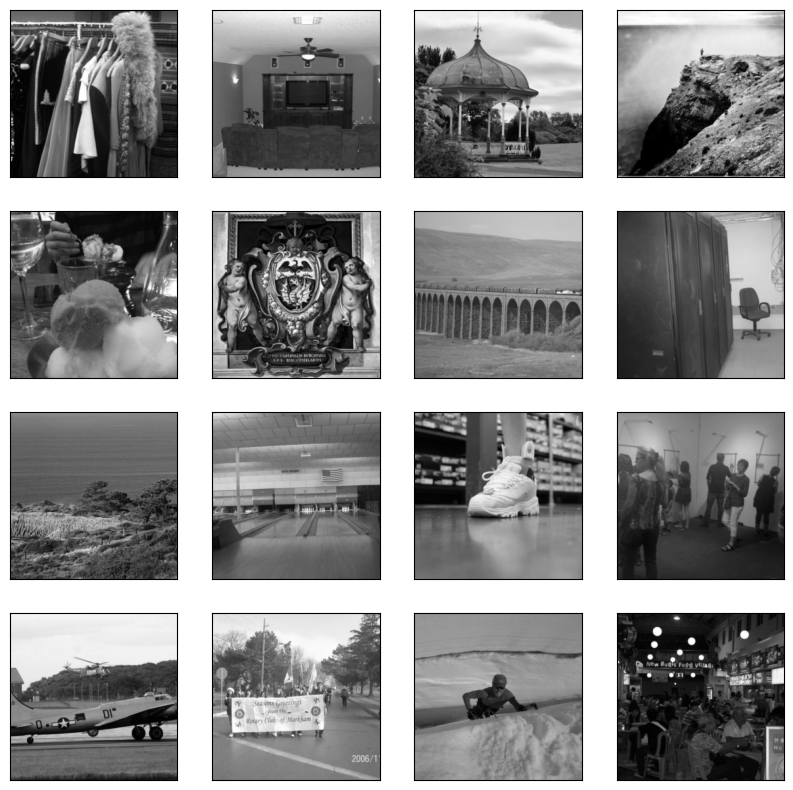

In [186]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
for i in range(16):
    randint = np.random.randint(len(full_dataset))
    image0 = full_dataset[randint][0].squeeze()
    #image0 = torch.einsum("cij->ijc", image0)
    axs[i//4][i%4].imshow(image0, cmap="grey", vmin=0, vmax=1)

# Remove axes labels
plt.setp(axs, xticks=[], yticks=[])

plt.show()

In [187]:
dataloader = torch.utils.data.DataLoader(full_dataset, batch_size=64, shuffle=True)

In [188]:
def get_mu_and_std(dataloader, N=256, device="mps"):
    """
    Returns the means and standard deviations of the image set as a tuple (means, stds)
    Note: returns the pixel-wise values (mean and std for each pixel) not the total image mean and std. 
    """

    mu = torch.zeros(N,N, device=device)
    std_squared = torch.zeros_like(mu)
    
    t0 = time.time()
    data_iter = iter(dataloader)
    for n in range(len(data_iter)):
        x = next(data_iter)[0].squeeze().to(device)
        _mu = x.mean(dim=0)
        mu = (mu*n + _mu)/(n+1)
        if n%50==0:
            print(f"Calculating mean ... {n}/{len(data_iter)}")
            clear_output(wait=True)
        
    data_iter = iter(dataloader)
    for n in range(len(data_iter)):
        x = next(data_iter)[0].squeeze().to(device)
        batch_size = x.shape[0]
        _std_squared = torch.einsum("bij,bij->ij", x-mu, x-mu)/batch_size
        std_squared = (std_squared*n + _std_squared)/(n+1)
        if n%50==0:
            print(f"Calculating standard deviation ... {n}/{len(data_iter)}")
            clear_output(wait=True)
    
    std = torch.sqrt(std_squared)
    print(f"Calculated mean and standard deviation in {time.time()-t0} seconds.")

    return mu, std

In [189]:
def get_sigma(dataloader, mu, std, batch_size=64, N=256, normalize=True, device="mps", realFFT=True):
    """
    Gets the Sigma tensor for a real image set.
    """
    b = batch_size
    sigma = torch.zeros(N,N,N,N).to(device)
    _sigma = torch.zeros(N,N,N,N).to(device)

    t0=time.time()
    t_last=t0
    data_iter = iter(dataloader)
    
    n=0
    for i in range(len(data_iter)):
        image_batch, _ = next(data_iter)
        image_batch = image_batch.to(device)
        
        mu = mu.to(device)
        std = std.to(device)
        X = image_batch.squeeze()-mu
        if normalize:
            X = X/std
        
        if realFFT:
            X = rfft(X)
            
        _sigma = torch.einsum("bij,bkl->ijkl", X, X)
        sigma = (sigma*n + _sigma)/(n+b)
        
        n+=b
        
        if i%100 == 0:
            t1 = time.time()
            print(f"{i}/{len(data_iter)} || Time Elapsed = {t1-t_last}")
            clear_output(wait=True)
            t_last=time.time()
            
    print(f"Completed in {time.time()-t0} seconds.")
    
    return sigma

In [190]:
mu,std = get_mu_and_std(dataloader)

Calculated mean and standard deviation in 19318.45175075531 seconds.


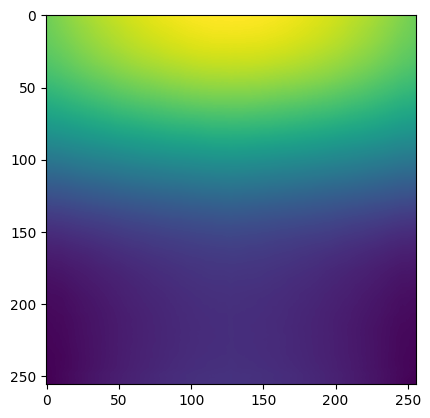

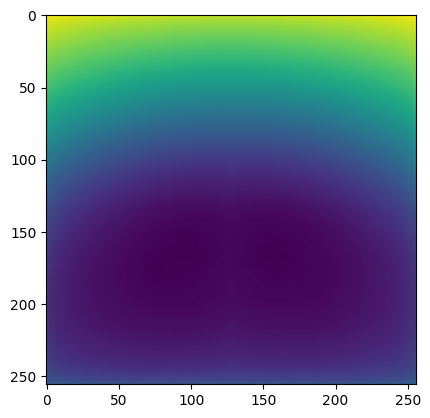

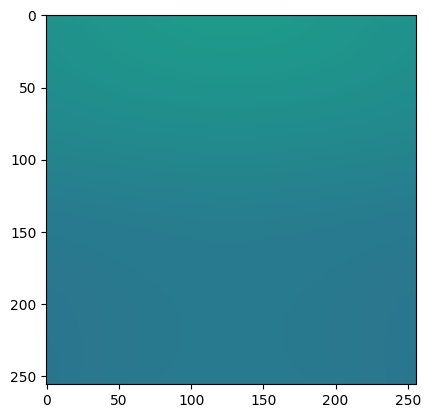

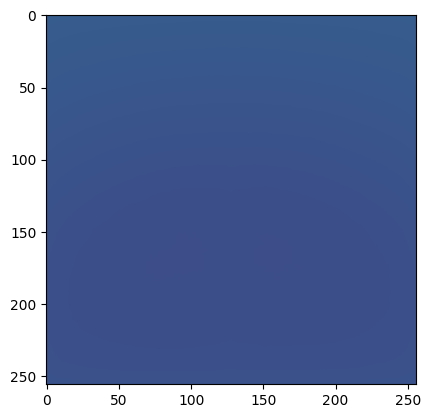

In [196]:
plt.imshow(mu.to("cpu"))
plt.show()

plt.imshow(std.to("cpu"))
plt.show()

plt.imshow(mu.to("cpu"), vmin=0, vmax=1)
plt.show()

plt.imshow(std.to("cpu"), vmin=0, vmax=1)
plt.show()